# **Preparing Dependencies**

In [1]:
# If dependencies are missing, install with uv in terminal:
# uv add torch diffusers transformers accelerate safetensors

import torch
from diffusers import StableDiffusionPipeline
from IPython.display import display

d:\Projects\VSCode Projects\idcamp-image-generation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`CLIPImageProcessor` requires torchvision (not installed); falling back to `CLIPImageProcessorPil` for backward compatibility. Install torchvision to use the default backend, or import `CLIPImageProcessorPil` directly to silence this warning.
`SiglipImageProcessor` requires torchvision (not installed); falling back to `SiglipImageProcessorPil` for backward compatibility. Install torchvision to use the default backend, or import `SiglipImageProcessorPil` directly to silence this warning.


# **Kriteria 1: Melakukan Image Generation dari Teks (Text-to-Image)**

## **Load Base Pipeline Model**

In [2]:
MODEL_ID = "runwayml/stable-diffusion-v1-5"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
 )
pipe = pipe.to(DEVICE)


d:\Projects\VSCode Projects\idcamp-image-generation\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Istamosh\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 396/396 [00:00<00:00, 3664.19it/s]4.50it/s]

## **Generate Image**

100%|██████████| 50/50 [07:28<00:00,  8.98s/it]


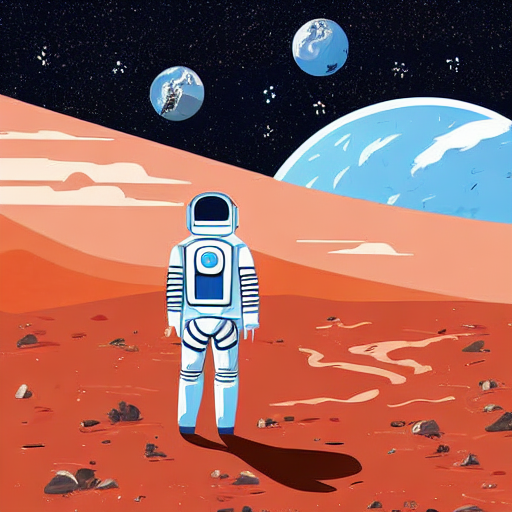

In [5]:
def generate_simple_image(prompt: str, negative_prompt: str = "", seed: int = 42):
    generator_device = "cuda" if DEVICE == "cuda" else "cpu"
    generator = torch.Generator(device=generator_device).manual_seed(int(seed))

    result = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        generator=generator,
    )
    return result.images[0]

TARGET_PROMPT = (
    "an astronaut in a white spacesuit walking on the surface of Mars, "
    "large blue Earth visible in the background, black starry sky, "
    "2D digital illustration, clean art style, flat colors"
)
TARGET_NEGATIVE_PROMPT = (
    "photorealistic, realistic, photograph, 3D render, messy, blurry, "
    "low quality, bad art, ugly, sketch, grainy, unfinished, chromatic aberration"
)
TARGET_SEED = 222

simple_image = generate_simple_image(
    prompt=TARGET_PROMPT,
    negative_prompt=TARGET_NEGATIVE_PROMPT,
    seed=TARGET_SEED,
)
display(simple_image)

## **Generate Image with Hyperparameter Configuration**

100%|██████████| 100/100 [15:02<00:00,  9.03s/it]


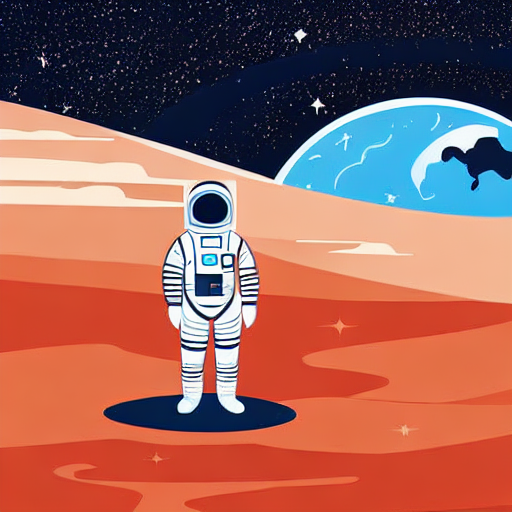

In [7]:
def generate_advanced_image(
    prompt: str,
    negative_prompt: str = "",
    seed: int = 42,
    guidance_scale: float = 7.5,
    num_inference_step: int = 50,
):
    generator_device = "cuda" if DEVICE == "cuda" else "cpu"
    generator = torch.Generator(device=generator_device).manual_seed(int(seed))

    result = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        generator=generator,
        guidance_scale=float(guidance_scale),
        num_inference_steps=int(num_inference_step),
    )
    return result.images[0]

advanced_image = generate_advanced_image(
    prompt=TARGET_PROMPT,
    negative_prompt=TARGET_NEGATIVE_PROMPT,
    seed=TARGET_SEED,
    guidance_scale=8.5,
    num_inference_step=100,
)
display(advanced_image)

## **Guidance Scale Comparison**

### **Guidance Scale Explanation:**

*   **Gambar dengan "Scale" Rendah:**   
*"Jelaskan karakteristik gambar yang dihasilkan, seperti tingkat detail, kesesuaian dengan prompt, dan variasi visual yang terlihat."*

*   **Gambar dengan "Scale" Tinggi:**   
*"Jelaskan perbedaan yang terlihat dibandingkan guidance scale rendah, terutama pada detail gambar dan kedekatannya dengan prompt."*

## **Inference Steps Comparison**

### **Inference Step Explanation:**

*   **Gambar dengan "Step" Rendah:**  
*"Jelaskan karakteristik gambar yang dihasilkan, seperti tingkat detail, ketajaman, serta kemungkinan munculnya noise atau artefak."*
*   **Gambar dengan "Step" Tinggi:**  
*"Jelaskan perbedaan yang terlihat dibandingkan step rendah, terutama pada detail gambar, kehalusan hasil, dan stabilitas visual."*

## **Batch Inference from One Prompt**

## **Load Scheduler**

### **Scheduler Comparation:**

*   **Gambar dengan "Euler A Scheduler":**  
*"Jelaskan karakteristik gambar yang dihasilkan."*
*   **Gambar dengan "DPM++ Scheduler":**  
*"Jelaskan karakteristik gambar yang dihasilkan."*
*   **Gambar dengan "DDIM Scheduler":**  
*"Jelaskan karakteristik gambar yang dihasilkan."*

# **Kriteria 2: Menyempurnakan Gambar Melalui Image-to-Image**

## **Base + Refiner Image Generation**

## **Inpainting**

### **Load Model Inpainting**

In [8]:
from diffusers import StableDiffusionInpaintPipeline

INPAINT_MODEL_ID = "runwayml/stable-diffusion-inpainting"

inpaint_pipe = StableDiffusionInpaintPipeline.from_pretrained(
    INPAINT_MODEL_ID,
    torch_dtype=DTYPE,
)
inpaint_pipe = inpaint_pipe.to(DEVICE)


def inpaint_engine(image, mask, prompt, negative_prompt="", seed=42):
    generator_device = "cuda" if DEVICE == "cuda" else "cpu"
    generator = torch.Generator(device=generator_device).manual_seed(int(seed))

    result = inpaint_pipe(
        prompt=prompt,
        image=image,
        mask_image=mask,
        negative_prompt=negative_prompt,
        generator=generator,
    )
    return result.images[0]

d:\Projects\VSCode Projects\idcamp-image-generation\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Istamosh\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]An

### **Manual Masking**

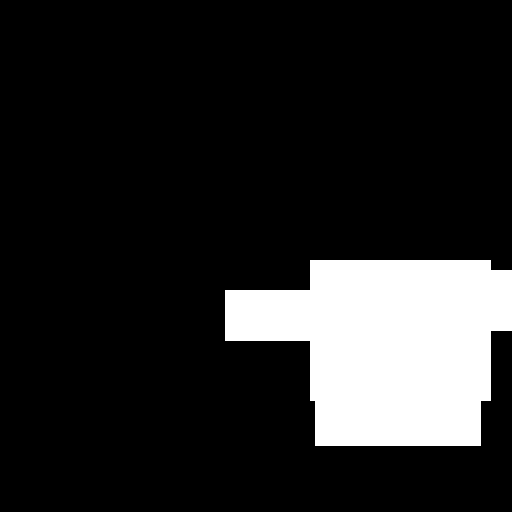

In [13]:
from PIL import Image, ImageDraw

# simple_image is 512x512; white = repaint, black = keep.
# Place the satellite clearly to the right of the astronaut on the Mars surface.
w, h = simple_image.size  # 512x512

mask = Image.new("RGB", (w, h), "black")
draw = ImageDraw.Draw(mask)

# Large satellite body on the ground
draw.rectangle([310, 260, 490, 400], fill="white")
# Left solar panel stretching toward the astronaut
draw.rectangle([225, 290, 315, 340], fill="white")
# Right solar panel stretching outward (partially off-canvas is fine)
draw.rectangle([488, 270, 512, 330], fill="white")
# Debris pile below the body
draw.rectangle([315, 395, 480, 445], fill="white")

display(mask)

### **Generate**

100%|██████████| 50/50 [07:15<00:00,  8.71s/it]


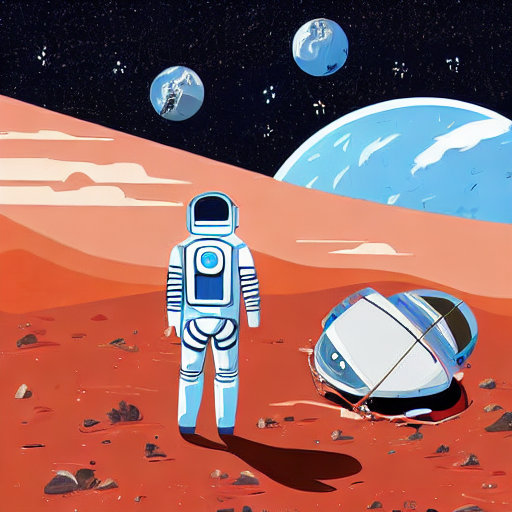

In [14]:
INPAINT_PROMPT = (
    "a wrecked satellite sitting on red Martian soil next to an astronaut, "
    "large golden solar panels bent outward to both sides, central metallic body, "
    "crash debris and broken parts on the ground, "
    "2D digital illustration, clean flat color art style"
)
INPAINT_NEGATIVE_PROMPT = (
    "photorealistic, realistic, photograph, 3D render, messy, blurry, "
    "low quality, bad art, ugly, sketch, grainy, unfinished, chromatic aberration"
)

inpainted_image = inpaint_engine(
    image=simple_image,
    mask=mask,
    prompt=INPAINT_PROMPT,
    negative_prompt=INPAINT_NEGATIVE_PROMPT,
    seed=9,
)
display(inpainted_image)

## **Inpainting Menggunakan Automasking**

### **load Model Segmentation Untuk Masking**

### **Masking with Segmentation Model**

### **Generate**

## **Outpainting**

### **Prepare the Canvas**

### **Generate**

## **Outpainting Zoom Out**

### **Prepare Canvas for Zoom Out**

### **Generate**